# Additional testing cases: built-in image on the page



## Set autoreload, library importing, logging, and environment 

In [15]:
# Enable autoreload to automatically pick up changes in local modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# Import libraries
import logging
from pathlib import Path
from IPython.display import display, Markdown, Image

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

from doc_agent.utils.logger import setup_logger
from doc_agent.data.docling_parser import parse_document
from utils.extract_page import extract_page_image
from utils.encode_image import encode_image_to_base64


# Configure logging
# Local notebook logger
logger = setup_logger(
    name="004_additional_testing_cases_4", 
    level=logging.INFO=,
    log_file="notebook_experiments.log",
    log_dir=Path.cwd() / "logs"
)

logger.info("Logging system successfully initialized.")

SyntaxError: invalid syntax (466325346.py, line 20)

## Workspace & Path Configuration
Setting up relative paths for raw documents, interim data (extracted images and Markdown), and processed outputs.

In [ ]:
# Paths relative to the notebook's location (notebooks/data/...)
notebook_root = Path.cwd()
# Path to the pdf-file
pdf_file = notebook_root / "data" / "01_raw" / "one_page_builtin_image.pdf"
logger.info(f"Path to the pdf-file: {pdf_file}")
# Path to the raw md-file
raw_markdown_file = notebook_root / "data" / "02_interim" / "one_page_builtin_image.md"
logger.info(f"Path to the md-file: {raw_markdown_file}")
# Path to the extracted page images
page_images_dir = notebook_root / "data" / "02_interim" / "page_images" 
logger.info(f"Path to the page images directory: {page_images_dir}")

docling_images_dir = notebook_root / "data" / "02_interim" / "docling_images"
logger.info(f"Path to the docling images directory: {docling_images_dir}")


2026-05-06 17:50:41 |     INFO | 004_additional_testing_cases_4:250696298.py:5 - Path to the pdf-file: /Volumes/SSD/AI/doc_agent/notebooks/data/01_raw/one_page_builtin_image.pdf
2026-05-06 17:50:41 |     INFO | 004_additional_testing_cases_4:250696298.py:8 - Path to the md-file: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/one_page_builtin_image.md
2026-05-06 17:50:41 |     INFO | 004_additional_testing_cases_4:250696298.py:11 - Path to the page images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/page_images
2026-05-06 17:50:41 |     INFO | 004_additional_testing_cases_4:250696298.py:14 - Path to the docling images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/docling_images


In [ ]:
logger.info("Starting document parsing process to extract AST...")

# 1. Configure parser options 
pipeline_options = PdfPipelineOptions()
pipeline_options.do_formula_enrichment = True
pipeline_options.generate_picture_images = True
pipeline_options.do_ocr = False # Disable aggressive OCR for schematics

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# 2. Parse the document and retrieve the raw AST (graph)
result = converter.convert(pdf_file)
doc = result.document

logger.info("AST extraction completed")

# 3. Export the raw md-file
raw_markdown_content = doc.export_to_markdown()
raw_markdown_file.write_text(raw_markdown_content, encoding="utf-8")
logger.info(f"Raw markdown successfully saved to {raw_markdown_file.name}")

2026-05-06 17:50:41 |     INFO | 004_additional_testing_cases_4:1272657087.py:1 - Starting document parsing process to extract AST...
2026-05-06 17:51:27 |     INFO | 004_additional_testing_cases_4:1272657087.py:19 - AST extraction completed
2026-05-06 17:51:27 |     INFO | 004_additional_testing_cases_4:1272657087.py:24 - Raw markdown successfully saved to one_page_builtin_image.md


## Create JSON dump from docling structure

In [ ]:
import json

with open(notebook_root / "data" / "02_interim" / "ast_dump.json", "w", encoding="utf-8") as f:
    json.dump(doc.export_to_dict(), f, indent=2, ensure_ascii=False)
    
logger.info("JSON dump created.")

2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:3465166242.py:6 - JSON dump created.


## Semantic XML Tagging Execution
Now we apply the `generate_tagged_markdown` function to our parsed `docling` object. 
This step iterates through the document's AST and wraps each semantic block in unique XML-like tags (e.g., `<text_1>...</text_1>`). As a result, we obtain a rigid markup ("factura") that creates ironclad attention boundaries, preventing the VLM from losing context or shuffling paragraphs during the healing phase.

In [ ]:
from utils.genetate_tagged_markdown import generate_tagged_markdown

logger.info("Executing XML tagging process...")

# Define the output path for the tagged Markdown file
tagged_md_file = notebook_root / "data" / "02_interim" / f"{pdf_file.stem}_tagged.md"

# Generate the tagged content and persist it to disk
tagged_content = generate_tagged_markdown(
    doc=doc, 
    output_path=tagged_md_file
)

logger.info(f"Tagged markdown successfully generated and saved to {tagged_md_file.name}")
logger.info(f"Total length of tagged content: {len(tagged_content)} characters")

# Render a preview of the resulting tagged text (first 1000 characters)
logger.info("Rendering preview of the tagged markdown:")
print(tagged_content[:1000] + "\n\n... (text truncated for preview)")

2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:446513549.py:3 - Executing XML tagging process...
2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:446513549.py:14 - Tagged markdown successfully generated and saved to one_page_builtin_image_tagged.md
2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:446513549.py:15 - Total length of tagged content: 3914 characters
2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:446513549.py:18 - Rendering preview of the tagged markdown:
<caption_1>
Рис . 1.7.6. Зона досягаемости в электроустановках до 1 кВ :
</caption_1>

<text_1>
S -поверхность , на которой может находиться человек ; B -основание поверхности S ;
</text_1>

<text_2>
-граница зоны досягаемости токоведущих частей рукой человека , находящегося на поверхности S ; 0,75; 1,25; 2,50 м -расстояния от края поверхности S до границы зоны досягаемости
</text_2>

<text_3>
прямого прикосновения к токоведущим частям или приближения к ним на 

## Extract the target page as a PNG image using PyPDFium2

2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:677466353.py:1 - Starting image extraction  from one_page_builtin_image.pdf...
2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:677466353.py:9 - Image extraction complete. Rendering preview...


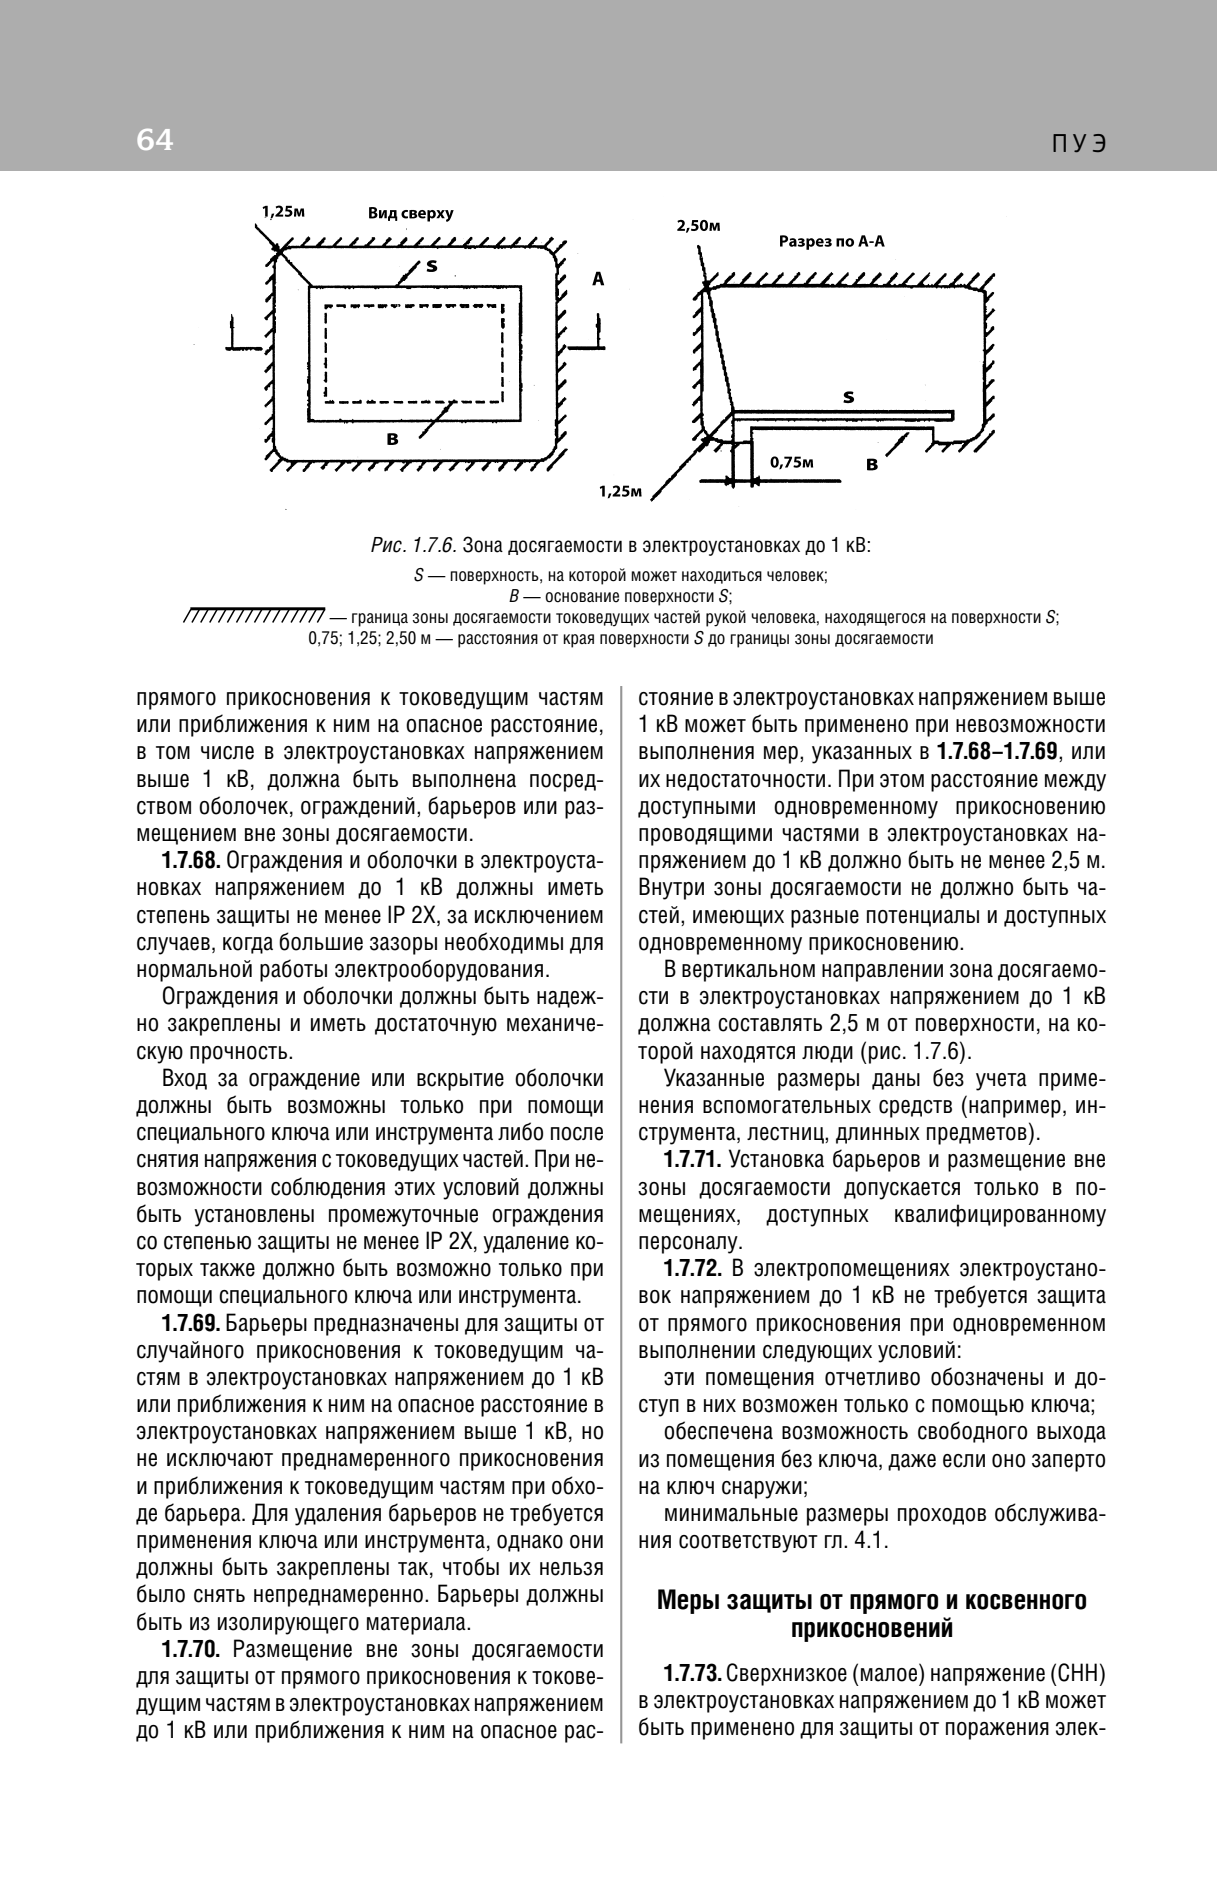

In [ ]:
logger.info(f"Starting image extraction  from {pdf_file.name}...")

# Extract the target page as a PNG image
target_image = extract_page_image(
    pdf_path=pdf_file, 
    output_dir=page_images_dir
)

logger.info("Image extraction complete. Rendering preview...")

# Display the extracted image inline
display(Image(filename=target_image, width=800))

## Preparing Inputs for the Vision-Language Model (VLM)
Loading the saved Markdown into memory and converting the target image into a base64 string required by the OpenAI API spec.

In [ ]:
# Load raw text
raw_markdown = raw_markdown_file.read_text(encoding="utf-8")
logger.info(f"Loaded raw Markdown: {len(raw_markdown)} characters.")

# Convert image to Base64
base64_image = encode_image_to_base64(target_image)
logger.info("Page image successfully encoded to Base64.")

2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:2864798789.py:3 - Loaded raw Markdown: 3528 characters.
2026-05-06 17:51:28 |     INFO | 004_additional_testing_cases_4:2864798789.py:7 - Page image successfully encoded to Base64.


## Agent Inference with Tagged Source Data
Now that we have the tagged text (Tagged MD), we send it to the VLM. We use a Native CoT approach (without rigid JSON-CoT) because the tags already provide the model with an excellent structure for maintaining focus.

In [25]:
import os
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List

# Setup API Client (assuming dotenv is loaded at the top of notebook)
client = OpenAI(
    api_key=os.environ.get("NANOGPT_API_KEY"),
    base_url=os.environ.get("NANOGPT_BASE_URL") 
)

TARGET_MODEL = "openai/gpt-5-mini" # The main model
# TARGET_MODEL = "google/gemini-flash-latest"
# TARGET_MODEL = "google/gemini-flash-lite-latest"
# TARGET_MODEL = "openai/gpt-5.4-nano"
# TARGET_MODEL = "Qwen/Qwen3.6-35B-A3B"
# TARGET_MODEL = "moonshotai/kimi-k2.6:thinking"
# TARGET_MODEL = "gemini-2.5-flash-preview-09-2025"
# TARGET_MODEL = "openai/gpt-5.4-mini"
# Use Native CoT prompt
prompt_file_cot = notebook_root / "prompts" / "semantic_normalization_native_cot_tagged.md"
system_prompt_cot = prompt_file_cot.read_text(encoding="utf-8")

class NormalizationResultLight(BaseModel):
    clean_markdown: str = Field(
        description="Final, structurally corrected Markdown text WITHOUT any XML tags."
    )

logger.info("Pydantic schema and prompts updated for Tagged processing.")

2026-05-06 21:28:04 |     INFO | 004_additional_testing_cases_4:1243371500.py:29 - Pydantic schema and prompts updated for Tagged processing.


In [26]:
from utils.encode_image import encode_image_to_base64
from utils.display_diff import display_diff

# Encode image
target_image = page_images_dir / f"{pdf_file.stem}_highres.png"
base64_image = encode_image_to_base64(target_image)

logger.info(f"Initiating inference with Tagged MD using model: {TARGET_MODEL}")

try:
    messages = [
        {"role": "system", "content": system_prompt_cot},
        {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": f"Raw Tagged Markdown for processing:\n\n{tagged_content}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high"
                    }
                }
            ]
        }
    ]

    response = client.chat.completions.parse(
        model=TARGET_MODEL,
        messages=messages,
        temperature=0.0,
        response_format=NormalizationResultLight,
    )

    tagged_normalized_data = response.choices[0].message.parsed
    logger.info("Inference complete. Checking output...")
    
    # Save the result
    processed_dir = notebook_root / "data" / "03_processed"
    final_output_file = processed_dir / f"{pdf_file.stem}_clean_tagged.md"
    final_output_file.write_text(tagged_normalized_data.clean_markdown, encoding="utf-8")
    
    logger.info(f"Saved to: {final_output_file.name}")

    # Visual Diff: Compare the raw md-file (no tags) and the cleaned md-file
    raw_untagged_md = raw_markdown_file.read_text(encoding="utf-8")
    
    display_diff(
        text_before=raw_untagged_md, 
        text_after=tagged_normalized_data.clean_markdown,
        fromfile='Raw_Docling_Untagged',
        tofile='LLM_Healed_via_Tags'
    )

except Exception as e:
    logger.error(f"Inference failed. Error: {e}", exc_info=True)

2026-05-06 21:28:04 |     INFO | 004_additional_testing_cases_4:3722612486.py:8 - Initiating inference with Tagged MD using model: openai/gpt-5-mini
2026-05-06 21:28:52 |     INFO | 004_additional_testing_cases_4:3722612486.py:39 - Inference complete. Checking output...
2026-05-06 21:28:52 |     INFO | 004_additional_testing_cases_4:3722612486.py:46 - Saved to: one_page_builtin_image_clean_tagged.md


```diff
--- Raw_Docling_Untagged
+++ LLM_Healed_via_Tags
@@ -1,39 +1,43 @@
-Рис . 1.7.6. Зона досягаемости в электроустановках до 1 кВ :
+**==PICTURE_PLACEHOLDER==**
 
-<!-- image -->
+Рис. 1.7.6. Зона досягаемости в электроустановках до 1 кВ: S — поверхность, на которой может находиться человек; B — основание поверхности S; — граница зоны досягаемости токоведущих частей рукой человека, находящегося на поверхности S; 0,75; 1,25; 2,50 м — расстояния от края поверхности S до границы зоны досягаемости.
 
-S -поверхность , на которой может находиться человек ; B -основание поверхности S ;
+Защита от прямого прикосновения к токоведущим частям или приближения к ним на опасное расстояние, в том числе в электроустановках напряжением выше 1 кВ, должна быть выполнена посредством оболочек, ограждений, барьеров или размещением вне зоны досягаемости.
 
--граница зоны досягаемости токоведущих частей рукой человека , находящегося на поверхности S ; 0,75; 1,25; 2,50 м -расстояния от края поверхности S до границы зоны досягаемости
+### 1.7.68. Ограждения и оболочки в электроустановках напряжением до 1 кВ
 
-прямого прикосновения к токоведущим частям или приближения к ним на опасное расстояние , в том числе в электроустановках напряжением выше 1 кВ , должна быть выполнена посред -ством оболочек , ограждений , барьеров или раз -мещением вне зоны досягаемости .
+Ограждения и оболочки в электроустановках напряжением до 1 кВ должны иметь степень защиты не менее IP2X, за исключением случаев, когда большие зазоры необходимы для нормальной работы электрооборудования.
 
-1.7.68. Ограждения и оболочки в электроуста -новках напряжением до 1 кВ должны иметь степень защиты не менее IP 2 Х , за исключением случаев , когда большие зазоры необходимы для нормальной работы электрооборудования .
+Ограждения и оболочки должны быть надежно закреплены и иметь достаточную механическую прочность.
 
-Ограждения и оболочки должны быть надеж -но закреплены и иметь достаточную механиче -скую прочность .
+Вход за ограждение или вскрытие оболочки должны быть возможны только при помощи специального ключа или инструмента либо после снятия напряжения с токоведущих частей. При невозможности соблюдения этих условий должны быть установлены промежуточные ограждения со степенью защиты не менее IP2X, удаление которых также должно быть возможно только при помощи специального ключа или инструмента.
 
-Вход за ограждение или вскрытие оболочки должны быть возможны только при помощи специального ключа или инструмента либо после снятия напряжения с токоведущих частей . При не -возможности соблюдения этих условий должны быть установлены промежуточные ограждения со степенью защиты не менее IP 2 Х , удаление ко -торых также должно быть возможно только при помощи специального ключа или инструмента .
+### 1.7.69. Барьеры
 
-1.7.69. Барьеры предназначены для защиты от случайного прикосновения к токоведущим ча -стям в электроустановках напряжением до 1 кВ или приближения к ним на опасное расстояние в электроустановках напряжением выше 1 кВ , но не исключают преднамеренного прикосновения и приближения к токоведущим частям при обхо -де барьера . Для удаления барьеров не требуется применения ключа или инструмента , однако они должны быть закреплены так , чтобы их нельзя было снять непреднамеренно . Барьеры должны быть из изолирующего материала .
+Барьеры предназначены для защиты от случайного прикосновения к токоведущим частям в электроустановках напряжением до 1 кВ или приближения к ним на опасное расстояние в электроустановках напряжением выше 1 кВ, но не исключают преднамеренного прикосновения и приближения к токоведущим частям при обходе барьера. Для удаления барьеров не требуется применения ключа или инструмента, однако они должны быть закреплены так, чтобы их нельзя было снять непреднамеренно. Барьеры должны быть из изолирующего материала.
 
-1.7.70. Размещение вне зоны досягаемости для защиты от прямого прикосновения к токове -дущим частям в электроустановках напряжением до 1 кВ или приближения к ним на опасное рас -
+### 1.7.70. Размещение вне зоны досягаемости
 
-стояние в электроустановках напряжением выше 1 кВ может быть применено при невозможности выполнения мер , указанных в 1.7.68-1.7.69 , или их недостаточности . При этом расстояние между доступными одновременному прикосновению проводящими частями в электроустановках на -пряжением до 1 кВ должно быть не менее 2,5 м . Внутри зоны досягаемости не должно быть ча -стей , имеющих разные потенциалы и доступных одновременному прикосновению .
+Размещение вне зоны досягаемости для защиты от прямого прикосновения к токоведущим частям в электроустановках напряжением до 1 кВ или приближения к ним на опасное расстояние в электроустановках напряжением выше 1 кВ может быть применено при невозможности выполнения мер, указанных в 1.7.68–1.7.69, или их недостаточности. При этом расстояние между доступными одновременному прикосновению проводящими частями в электроустановках напряжением до 1 кВ должно быть не менее 2,5 м. Внутри зоны досягаемости не должно быть частей, имеющих разные потенциалы и доступных одновременному прикосновению.
 
-В вертикальном направлении зона досягаемо -сти в электроустановках напряжением до 1 кВ должна составлять 2,5 м от поверхности , на ко -торой находятся люди ( рис . 1.7.6).
+В вертикальном направлении зона досягаемости в электроустановках напряжением до 1 кВ должна составлять 2,5 м от поверхности, на которой находятся люди (рис. 1.7.6).
 
-Указанные размеры даны без учета приме -нения вспомогательных средств ( например , ин -струмента , лестниц , длинных предметов ).
+Указанные размеры даны без учета применения вспомогательных средств (например, инструмента, лестниц, длинных предметов).
 
-1.7.71. Установка барьеров и размещение вне зоны досягаемости допускается только в по -мещениях , доступных квалифицированному персоналу .
+### 1.7.71. Установка барьеров и размещение вне зоны досягаемости
 
-1.7.72. В электропомещениях электроустано -вок напряжением до 1 кВ не требуется защита от прямого прикосновения при одновременном выполнении следующих условий :
+Установка барьеров и размещение вне зоны досягаемости допускается только в помещениях, доступных квалифицированному персоналу.
 
-эти помещения отчетливо обозначены и до -ступ в них возможен только с помощью ключа ;
+### 1.7.72. Электропомещения, доступные только по ключу
 
-обеспечена возможность свободного выхода из помещения без ключа , даже если оно заперто на ключ снаружи ;
+В электропомещениях электроустановок напряжением до 1 кВ не требуется защита от прямого прикосновения при одновременном выполнении следующих условий:
 
-минимальные размеры проходов обслужива -ния соответствуют гл . 4.1.
+- эти помещения отчетливо обозначены и доступ в них возможен только с помощью ключа;
+- обеспечена возможность свободного выхода из помещения без ключа, даже если оно заперто на ключ снаружи;
+- минимальные размеры проходов обслуживания соответствуют гл. 4.1.
 
 ## Меры защиты от прямого и косвенного прикосновений
 
-1.7.73. Сверхнизкое ( малое ) напряжение ( СНН ) в электроустановках напряжением до 1 кВ может быть применено для защиты от поражения элек -
+### 1.7.73. Сверхнизкое (малое) напряжение (СНН)
+
+Сверхнизкое (малое) напряжение (СНН) в электроустановках напряжением до 1 кВ может быть применено для защиты от поражения элек-
```

# Improve prompt 

We are adding information about placeholders for images.

<div style="border: 2px solid #5c6bc0; border-radius: 8px; padding: 20px; background-color: rgba(92, 107, 192, 0.05); box-shadow: 0 4px 6px rgba(0,0,0,0.05); width: fit-content;">

<h3 style="margin-top: 0; color: #5c6bc0; border-bottom: 1px solid #5c6bc0; padding-bottom: 8px;">
  📤 Prompt 
</h3>

```xml
<system_role>
Алгоритм семантической нормализации инженерных данных (OCR Healing Engine).

Цель — преобразовать сырой текст, размеченный XML-подобными тегами, в чистый Markdown, используя изображение страницы для валидации структуры и форматирования. 
</system_role>


<structural_mapping>
- Изолированные математические выражения и формулы (дополнительным тригером можут служить теги <formula_> </formula_> в размеченном XML), обернуть в `$$`, преобразовав в Latex.

- Внутристрочные переменные обернуть в `$`, преобразовав в Latex.

- Востановить таблицы, имеющие невидимые границы.

- Разделение сложных таблиц: если одна ячейка визуально охватывает несколько строк в соседних колонках, запрещено сливать их текст. Разбить на отдельные Markdown-строки: значение общей ячейки писать только в первой строке, в последующих оставлять эту ячейку пустой.

- Подписи таблиц: текст типа "Таблица X.X.X" запрещено удалять или превращать в заголовок страницы/колонтитул (даже если первичный парсер разметил его соответствующим тегом). Оставлять его обычным текстом непосредственно перед самой Markdown-таблицей.

- При наличии схемы, чертежи и изображений на странице использовать плейсхолдлер `**==PICTURE_PLACEHOLDER==**` в этом месте. Подписи к изображениями разместить непосредственно под плейсхолдером.

- Выполнить нумерацию пунктов согласно таблице:
    `Раздел X.` => `#`
    `Глава X.X` => `##`
    `X.X.X` => `###`
    `X.`  => `####`
    Обеспечить логичекую последовательность нумерации пунктов.
    Иногда первичный парсер изображения при разметке текста ошибочно ставит теги <list_item_>  </list_item_> вместо <section_header_> </section_header_>, что приводит к неверной интерпретации вложенности пунктов. Учесть и исправить такие ситуации.
</structural_mapping>


<output_format>
Ответ сгенерировать строго в формате валидного JSON:
- "clean_markdown": (строка) Итоговый исправленный Markdown-текст.
</output_format>
```

</div>

<div style="border: 2px solid #388e3c; border-radius: 8px; padding: 20px; background-color: rgba(56, 142, 60, 0.05); box-shadow: 0 4px 6px rgba(0,0,0,0.05); width: fit-content;">

<h3 style="margin-top: 0; color: #388e3c; border-bottom: 1px solid #388e3c; padding-bottom: 8px;">
  📄 Output
</h3>

**==PICTURE_PLACEHOLDER==**

Рис. 1.7.6. Зона досягаемости в электроустановках до 1 кВ:

S — поверхность, на которой может находиться человек;

B — основание поверхности S;

— граница зоны досягаемости токоведущих частей рукой человека, находящегося на поверхности S;

0,75; 1,25; 2,50 м — расстояния от края поверхности S до границы зоны досягаемости.

Защита от прямого прикосновения к токоведущим частям или приближения к ним на опасное расстояние, в том числе в электроустановках напряжением выше 1 кВ, должна быть выполнена посредством оболочек, ограждений, барьеров или размещением вне зоны досягаемости.

### 1.7.68. Ограждения и оболочки в электроустановках напряжением до 1 кВ

Ограждения и оболочки в электроустановках напряжением до 1 кВ должны иметь степень защиты не менее IP2X, за исключением случаев, когда большие зазоры необходимы для нормальной работы электрооборудования.

Ограждения и оболочки должны быть надежно закреплены и иметь достаточную механическую прочность.

Вход за ограждение или вскрытие оболочки должны быть возможны только при помощи специального ключа или инструмента либо после снятия напряжения с токоведущих частей. При невозможности соблюдения этих условий должны быть установлены промежуточные ограждения со степенью защиты не менее IP2X, удаление которых также должно быть возможно только при помощи специального ключа или инструмента.

### 1.7.69. Барьеры

Барьеры предназначены для защиты от случайного прикосновения к токоведущим частям в электроустановках напряжением до 1 кВ или приближения к ним на опасное расстояние в электроустановках напряжением выше 1 кВ, но не исключают преднамеренного прикосновения и приближения к токоведущим частям при обходе барьера. Для удаления барьеров не требуется применения ключа или инструмента, однако они должны быть закреплены так, чтобы их нельзя было снять непреднамеренно. Барьеры должны быть из изолирующего материала.

### 1.7.70. Размещение вне зоны досягаемости

Размещение вне зоны досягаемости для защиты от прямого прикосновения к токоведущим частям в электроустановках напряжением до 1 кВ или приближения к ним на опасное расстояние в электроустановках напряжением выше 1 кВ может быть применено при невозможности выполнения мер, указанных в 1.7.68–1.7.69, или их недостаточности. При этом расстояние между доступными одновременному прикосновению проводящими частями в электроустановках напряжением до 1 кВ должно быть не менее 2,5 м. Внутри зоны досягаемости не должно быть частей, имеющих разные потенциалы и доступных одновременному прикосновению.

В вертикальном направлении зона досягаемости в электроустановках напряжением до 1 кВ должна составлять 2,5 м от поверхности, на которой находятся люди (рис. 1.7.6).

Указанные размеры даны без учета применения вспомогательных средств (например, инструмента, лестниц, длинных предметов).

### 1.7.71. Установка барьеров и размещение вне зоны досягаемости

Установка барьеров и размещение вне зоны досягаемости допускается только в помещениях, доступных квалифицированному персоналу.

### 1.7.72. Исключения в электропомещениях

В электропомещениях электроустановок напряжением до 1 кВ не требуется защита от прямого прикосновения при одновременном выполнении следующих условий:

- эти помещения отчетливо обозначены и доступ в них возможен только с помощью ключа;
- обеспечена возможность свободного выхода из помещения без ключа, даже если оно заперто на ключ снаружи;
- минимальные размеры проходов обслуживания соответствуют гл. 4.1.

## Меры защиты от прямого и косвенного прикосновений

### 1.7.73. Сверхнизкое (малое) напряжение (СНН)

Сверхнизкое (малое) напряжение (СНН) в электроустановках напряжением до 1 кВ может быть применено для защиты от поражения электрическим током.

</div>